## 1. Import Libraries

In [34]:
%pip install scikit-learn pandas numpy matplotlib seaborn joblib

In [35]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Saving/loading models
import joblib

# Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Loading the Data

The Adult Income dataset typically has these column names (note: some versions use hyphens, some underscores —
we standardize them right after loading).


In [36]:
DATA_PATH = r"C:\Users\nkemn\OneDrive\Documents\Salary_Prediction\adult.data"  # update this path if your file is located elsewhere

COLUMN_NAMES = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

try:
    df = pd.read_csv(r"C:\Users\nkemn\OneDrive\Documents\Salary_Prediction\adult.data",header=None,
        names=COLUMN_NAMES,
        na_values="?",
        skipinitialspace=True)
    # If the CSV has no header row, uncomment the line below instead:
    # df = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES, na_values=" ?", skipinitialspace=True)
except FileNotFoundError:
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Download 'adult.csv' from the Kaggle dataset page "
        "and place it in the same folder as this notebook, then re-run this cell."
    )

# Standardize column names (strip whitespace, lowercase, replace underscores with hyphens for consistency)
df.columns = [c.strip().lower().replace("_", "-") for c in df.columns]

print("Shape:", df.shape)
df.head()


Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3. Exploratory Data Analysis (EDA)

We start with a comprehensive look at the structure, types, and distributions in the data.


In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [38]:
df.describe(include='number').T


,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education-num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [39]:
df.describe(include='object').T


,count,unique,top,freq
workclass,30725,8,Private,22696
education,32561,16,HS-grad,10501
marital-status,32561,7,Married-civ-spouse,14976
occupation,30718,14,Prof-specialty,4140
relationship,32561,6,Husband,13193
race,32561,5,White,27816
sex,32561,2,Male,21790
native-country,31978,41,United-States,29170
income,32561,2,<=50K,24720


In [40]:
print("Dataset shape:", df.shape)
print("\nColumn data types:\n", df.dtypes)


Dataset shape: (32561, 15)

Column data types:
 age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object


In [41]:
# Unique value counts for categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"--- {col} ({df[col].nunique()} unique values) ---")
    print(df[col].value_counts().head(10))
    print()


--- workclass (8 unique values) ---
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

--- education (16 unique values) ---
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
Name: count, dtype: int64

--- marital-status (7 unique values) ---
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

--- occupation (14 unique values) ---
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      406

In [42]:
# Target variable distribution
target_col = "income"
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True) * 100)


income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


### 3.1 Target class balance

The target is imbalanced (roughly 75% `<=50K` vs 25% `>50K`), which we'll keep in mind during evaluation
(accuracy alone can be misleading — we'll rely on precision, recall, F1, and ROC-AUC as well).


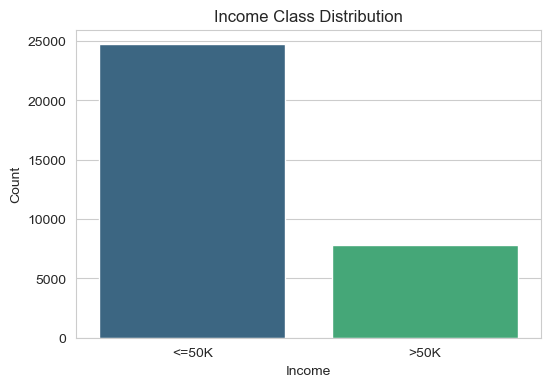

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col, palette="viridis")
plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()


In [44]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


## 4. Data Visualization

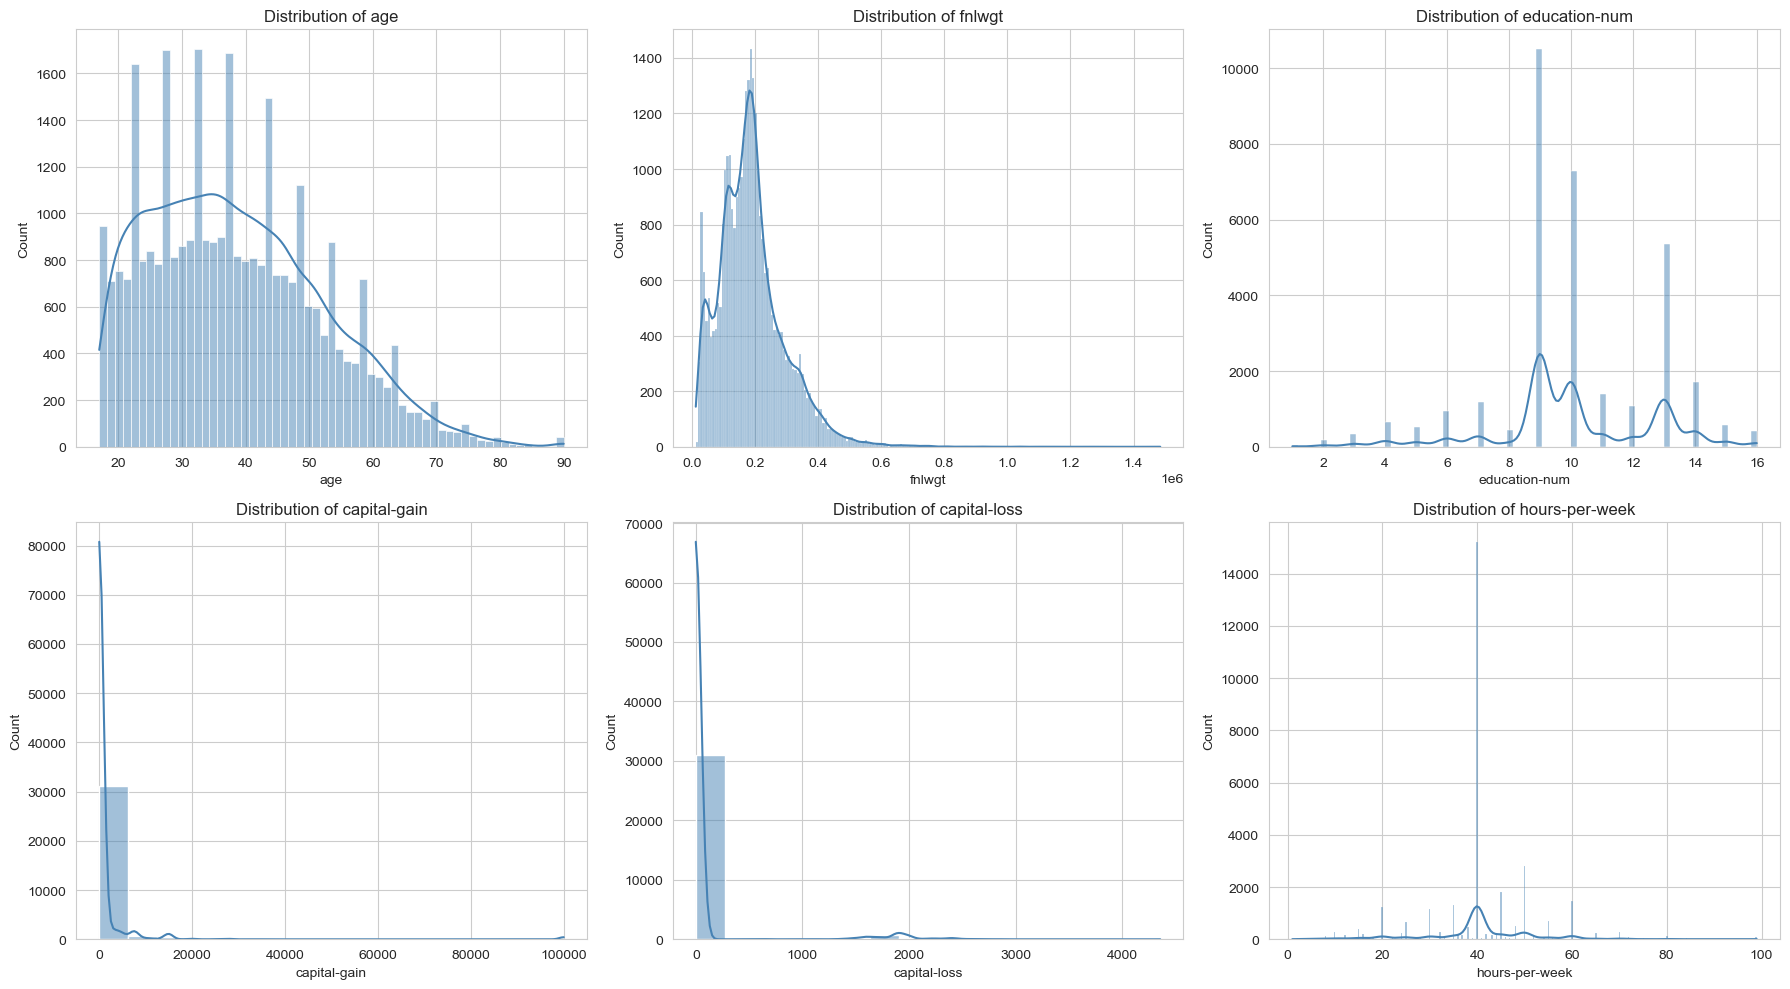

In [45]:
# Distribution of numerical features
num_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


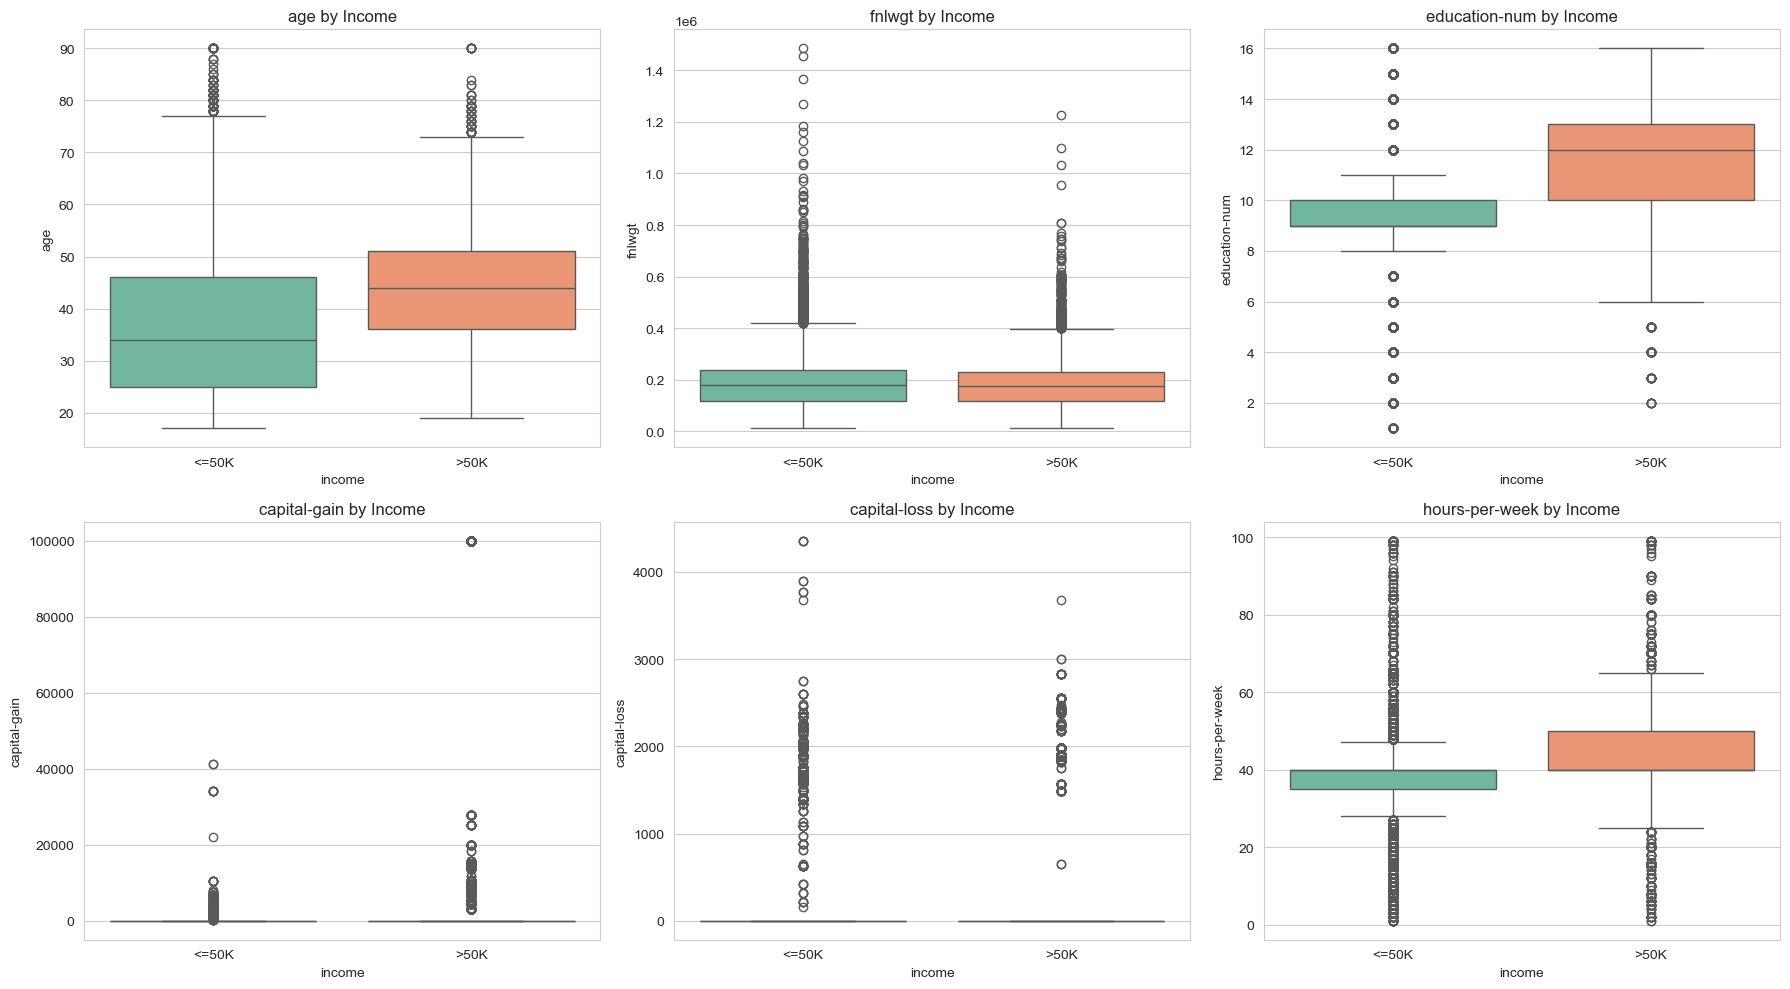

In [46]:
# Numerical features vs income
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} by Income")
plt.tight_layout()
plt.show()


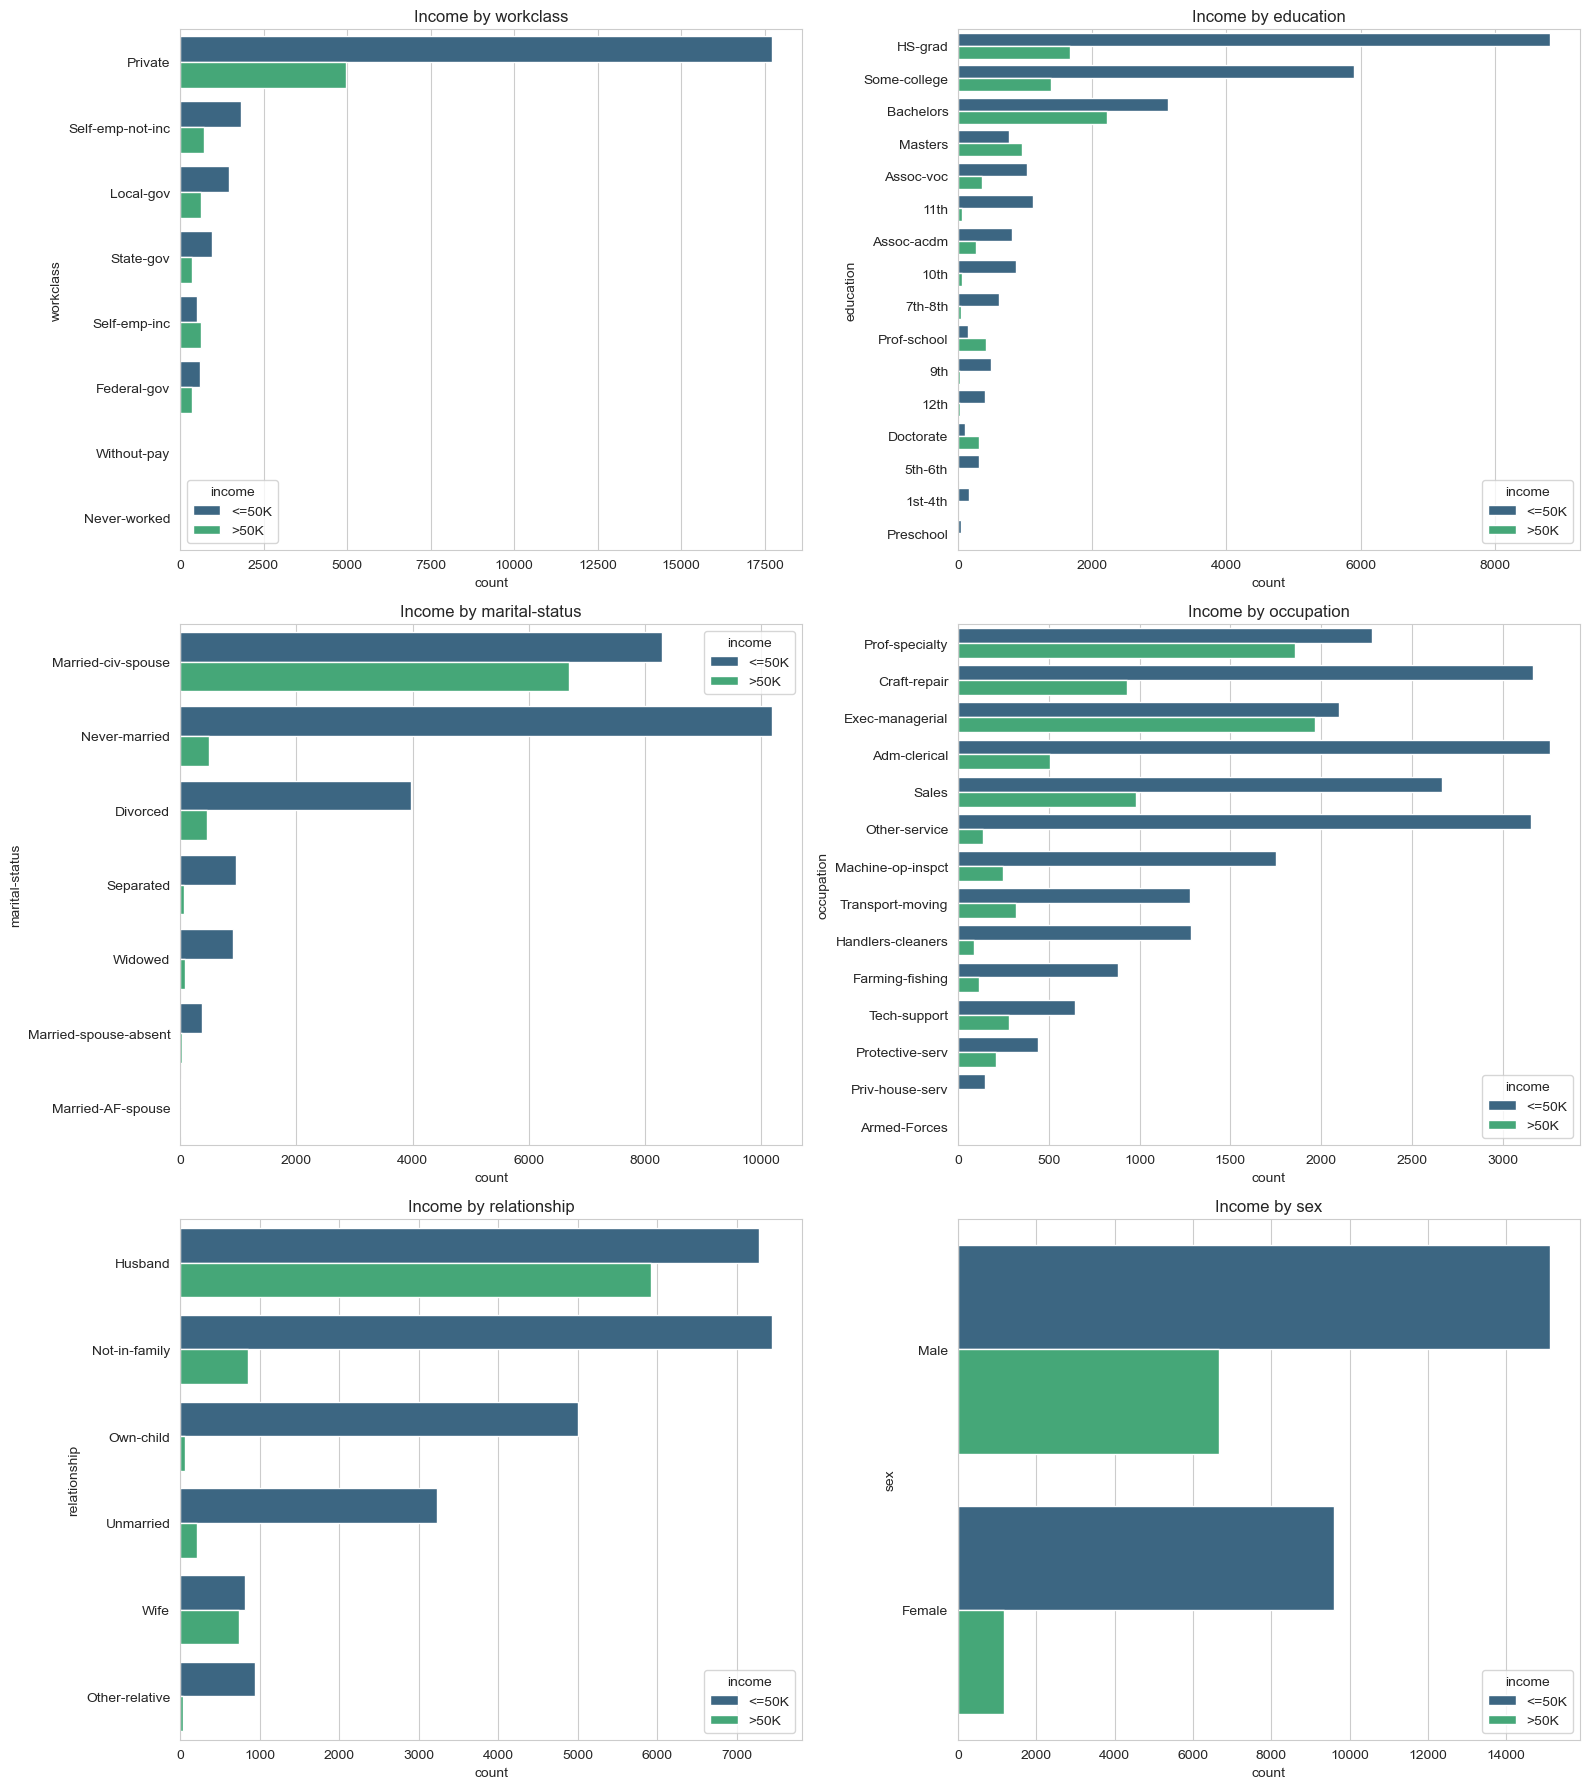

In [47]:
# Key categorical features vs income
cat_features_to_plot = ["workclass", "education", "marital-status", "occupation", "relationship", "sex"]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()
for i, col in enumerate(cat_features_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue=target_col, order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Income by {col}")
plt.tight_layout()
plt.show()


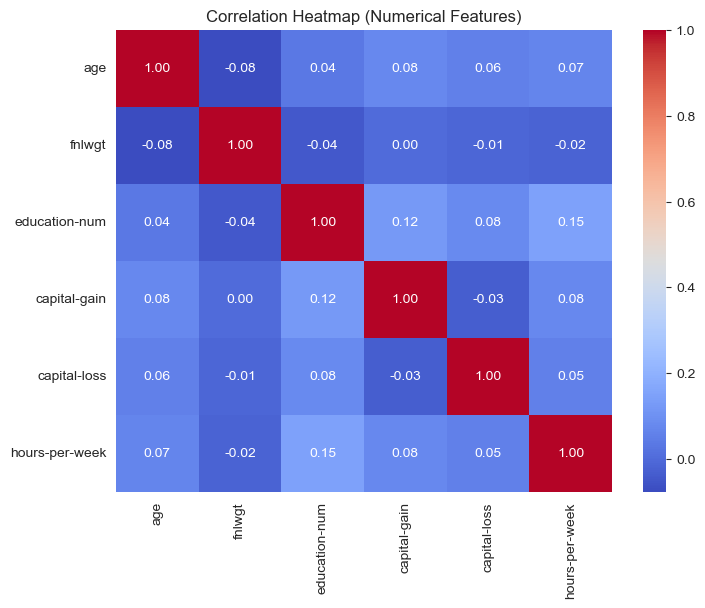

In [48]:
# Correlation heatmap for numerical features
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


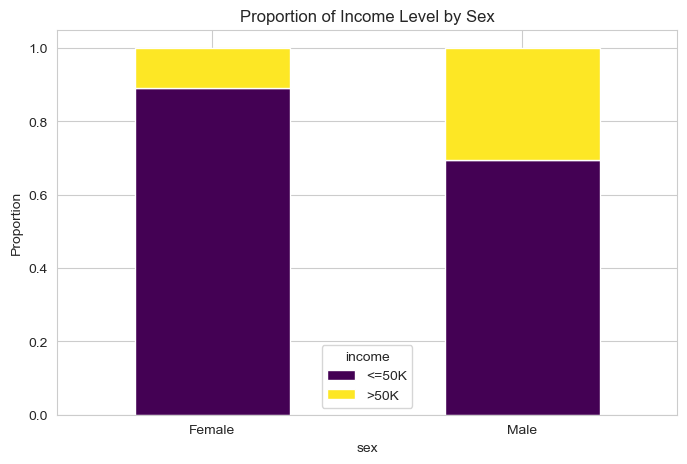

In [49]:
# Sex distribution across income (proportional)
pd.crosstab(df['sex'], df['income'], normalize='index').plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Proportion of Income Level by Sex")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()


## 5. Handling Missing Values

The Adult dataset commonly encodes missing values as the string `"?"` rather than `NaN`. We first
convert those, then inspect and handle the missingness.


In [50]:
# Replace '?' (with possible surrounding whitespace) with NaN
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_summary


,missing_count,missing_pct
occupation,1843,5.660146
workclass,1836,5.638647
native-country,583,1.790486


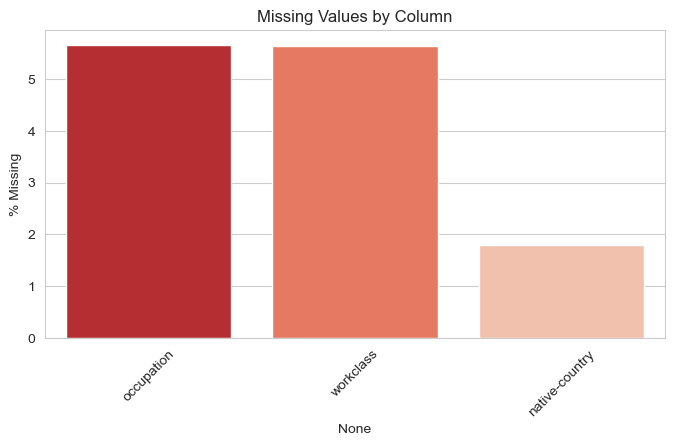

In [51]:
if not missing_summary.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing_summary.index, y=missing_summary["missing_pct"], palette="Reds_r")
    plt.ylabel("% Missing")
    plt.title("Missing Values by Column")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("No missing values detected.")


In [52]:
# Strategy: for categorical columns with missing values (typically workclass, occupation, native-country),
# impute with the mode (most frequent category). This preserves row count and is standard for this dataset.
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == "object":
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"Filled missing values in '{col}' with mode: '{mode_val}'")
        else:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"Filled missing values in '{col}' with median: {median_val}")

print("\nRemaining missing values:", df.isnull().sum().sum())


Filled missing values in 'workclass' with mode: 'Private'
Filled missing values in 'occupation' with mode: 'Prof-specialty'
Filled missing values in 'native-country' with mode: 'United-States'

Remaining missing values: 0


## 6. Detecting and Removing Duplicates

In [53]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows found.")


Number of duplicate rows: 24
Duplicates removed. New shape: (32537, 15)


## 7. Outlier Detection

We use the IQR (Interquartile Range) method to detect outliers in key numerical columns.
`capital-gain` and `capital-loss` are naturally very skewed (most values are 0 with a few large values),
so rather than blindly removing outliers there, we cap extreme values to reduce their influence while
keeping the signal that "some capital gain/loss" often correlates with higher income.


In [54]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper

outlier_check_cols = ["age", "hours-per-week", "capital-gain", "capital-loss"]
for col in outlier_check_cols:
    count, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {count} outliers (bounds: [{lower:.2f}, {upper:.2f}])")


age: 142 outliers (bounds: [-2.00, 78.00])
hours-per-week: 9002 outliers (bounds: [32.50, 52.50])
capital-gain: 2712 outliers (bounds: [0.00, 0.00])
capital-loss: 1519 outliers (bounds: [0.00, 0.00])


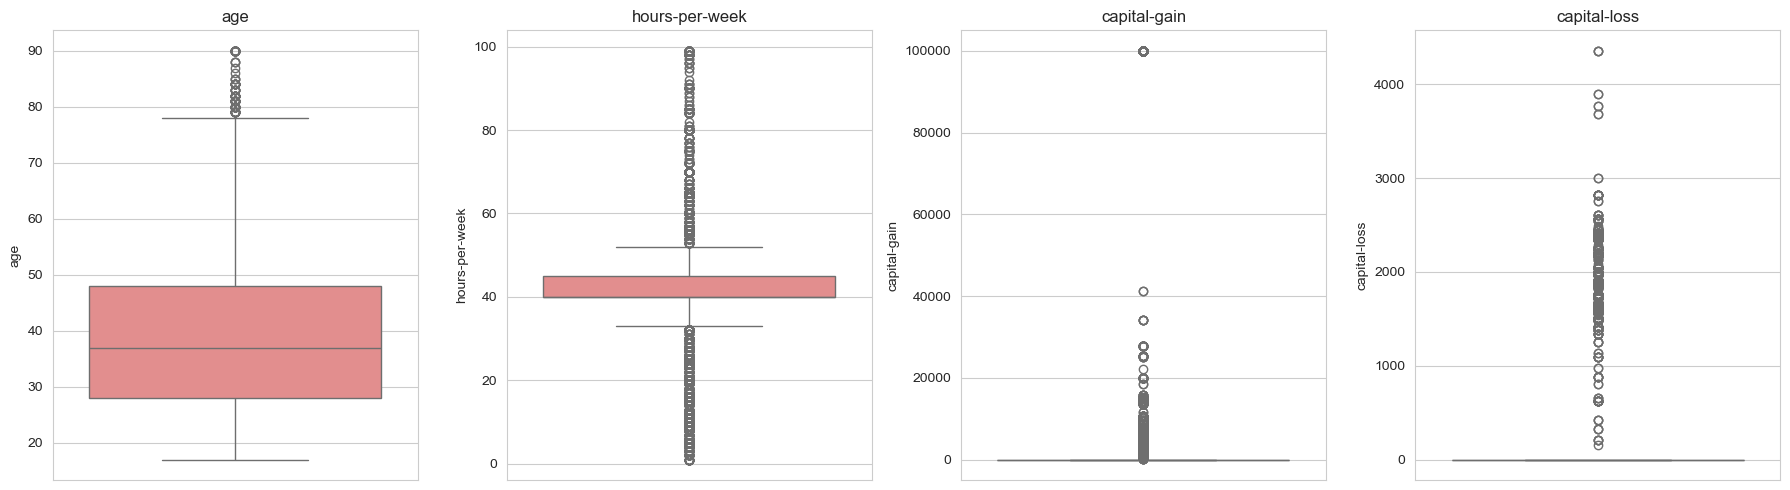

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(outlier_check_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


In [56]:
# Cap outliers using the IQR bounds (winsorization) instead of dropping rows,
# to avoid losing valuable minority-class (>50K) records that often have unusual capital-gain/hours values.
def cap_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower, upper)
    return data

for col in ["age", "hours-per-week"]:
    df = cap_outliers_iqr(df, col)

# capital-gain / capital-loss: cap at the 99th percentile instead (IQR bounds are near-zero for these
# since most values are 0, so IQR capping would wipe out the informative high-income signal entirely)
for col in ["capital-gain", "capital-loss"]:
    cap_value = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap_value)

print("Outlier treatment complete.")
df[outlier_check_cols].describe()


Outlier treatment complete.


,age,hours-per-week,capital-gain,capital-loss
count,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.559855,41.203246,634.278913,83.861880
std,13.554847,6.187352,2521.975203,383.089541
min,17.000000,32.500000,0.000000,0.000000
25%,28.000000,40.000000,0.000000,0.000000
50%,37.000000,40.000000,0.000000,0.000000
75%,48.000000,45.000000,0.000000,0.000000
max,78.000000,52.500000,15024.000000,1980.000000


## 8. Feature Engineering

In [57]:
# 1. Net capital gain (gain - loss) — a single feature capturing overall capital gain/loss
df["capital-net"] = df["capital-gain"] - df["capital-loss"]

# 2. Age groups — sometimes non-linear age effects are captured better with bins
df["age-group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
)

# 3. Work intensity — categorize hours-per-week
df["work-intensity"] = pd.cut(
    df["hours-per-week"],
    bins=[0, 20, 40, 60, 100],
    labels=["part-time", "full-time", "over-time", "extreme"]
)

# 4. Simplify marital status into a binary "is-married" flag (captures a strong signal in this dataset)
df["is-married"] = df["marital-status"].str.contains("Married", case=False, na=False).astype(int)

# 5. Has any capital activity (gain or loss)
df["has-capital-activity"] = ((df["capital-gain"] > 0) | (df["capital-loss"] > 0)).astype(int)

print("New engineered features:")
df[["capital-net", "age-group", "work-intensity", "is-married", "has-capital-activity"]].head()


New engineered features:


,capital-net,age-group,work-intensity,is-married,has-capital-activity
0,2174,35-44,full-time,1,1
1,0,45-54,full-time,1,0
2,0,35-44,full-time,0,0
3,0,45-54,full-time,1,0
4,0,25-34,full-time,1,0


In [ ]:
# fnlwgt is a census sampling weight, not a meaningful predictive feature for an individual's income 
# we drop it, along with the raw 'education' string column since 'education-num' already encodes it ordinally.
df = df.drop(columns=["fnlwgt", "education"])
df.head()


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,capital-net,age-group,work-intensity,is-married,has-capital-activity
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K,2174,35-44,full-time,1,1
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,32.5,United-States,<=50K,0,45-54,full-time,1,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K,0,35-44,full-time,0,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K,0,45-54,full-time,1,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K,0,25-34,full-time,1,0


## 9. Encoding Categorical Variables

- **Target (`income`)** → Label Encoding (binary: 0 = `<=50K`, 1 = `>50K`)
- **Categorical features** → One-Hot Encoding (via `ColumnTransformer`, applied inside the modeling pipeline
  so it's fit only on the training data and saved together with the model — this avoids data leakage).


In [59]:
# Label-encode the target
label_encoder = LabelEncoder()
df["income"] = df["income"].astype(str).str.strip()
df["income-encoded"] = label_encoder.fit_transform(df["income"])

print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X = df.drop(columns=["income", "income-encoded"])
y = df["income-encoded"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical features:", categorical_features)
print("Numerical features:", numerical_features)


Label mapping: {'<=50K': np.int64(0), '>50K': np.int64(1)}

Categorical features: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age-group', 'work-intensity']
Numerical features: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital-net', 'is-married', 'has-capital-activity']


## 10. Feature Scaling (via Preprocessing Pipeline)

We combine **One-Hot Encoding** (categorical) and **Standard Scaling** (numerical) into a single
`ColumnTransformer`. This preprocessor is placed inside each model's `Pipeline`, so scaling/encoding
is always fit on training data only and applied consistently at prediction time — including after
we reload the saved model.


In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss', 'hours-per-week',
                                  'capital-net', 'is-married',
                                  'has-capital-activity']),
                                ('cat',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore'),
                                 ['workclass', 'marital-status', 'occupation',
                                  'relationship', 'race', 'sex',
                                  'native-country', 'age-group',
                                  'work-intensity'])])

## 11. Train/Test Split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))


Training set: (26029, 17)
Test set: (6508, 17)

Training target distribution:
 income-encoded
0    0.759076
1    0.240924
Name: proportion, dtype: float64

Test target distribution:
 income-encoded
0    0.759066
1    0.240934
Name: proportion, dtype: float64


## 12. Training Multiple Algorithms

We train five classifiers, each wrapped in a `Pipeline` with the shared preprocessing step:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)


In [62]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42)
}

pipelines = {}
baseline_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    print(f"Trained: {name}")

baseline_df = pd.DataFrame(baseline_results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
baseline_df


Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: KNN
Trained: SVM


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.866779,0.785656,0.614796,0.689803,0.909473
1,Logistic Regression,0.861248,0.749437,0.637117,0.688728,0.917798
2,Random Forest,0.852182,0.716120,0.640306,0.676094,0.896381
3,KNN,0.844345,0.690984,0.640306,0.664681,0.874099
4,Decision Tree,0.821143,0.632720,0.614158,0.623301,0.770965


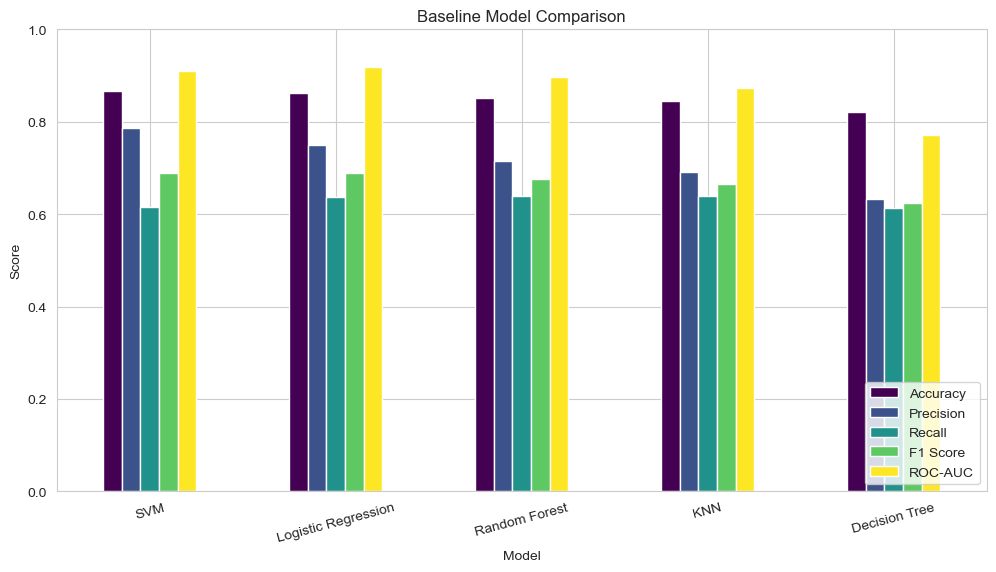

In [63]:
baseline_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(12, 6), colormap="viridis"
)
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()


## 13. Hyperparameter Tuning with GridSearchCV

We tune each model's key hyperparameters using 5-fold cross-validation, optimizing for **F1 score**
(a good balance for the moderately imbalanced target). 



In [65]:
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__solver": ["liblinear", "lbfgs"]
    },
    "Decision Tree": {
        "classifier__max_depth": [5, 10, 15, None],
        "classifier__min_samples_split": [2, 5, 10]
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [10, 20, None],
        "classifier__min_samples_split": [2, 5]
    },
    "KNN": {
        "classifier__n_neighbors": [5, 11, 21],
        "classifier__weights": ["uniform", "distance"]
    },
    "SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["rbf", "linear"]
    }
}

best_estimators = {}
tuned_results = []

for name, model in models.items():
    print(f"Tuning {name} ...")
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=param_grids[name],
        scoring="f1",
        cv=5,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_

    y_pred = grid.best_estimator_.predict(X_test)
    y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best CV F1: {grid.best_score_:.4f}\n")

tuned_df = pd.DataFrame(tuned_results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
tuned_df


Tuning Logistic Regression ...
  Best params: {'classifier__C': 1, 'classifier__solver': 'liblinear'}
  Best CV F1: 0.6714

Tuning Decision Tree ...
  Best params: {'classifier__max_depth': 15, 'classifier__min_samples_split': 10}
  Best CV F1: 0.6637

Tuning Random Forest ...
  Best params: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
  Best CV F1: 0.6740

Tuning KNN ...
  Best params: {'classifier__n_neighbors': 5, 'classifier__weights': 'uniform'}
  Best CV F1: nan

Tuning SVM ...
  Best params: {'classifier__C': 10, 'classifier__kernel': 'linear'}
  Best CV F1: 0.6715



,Model,Best Params,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,"{'classifier__max_depth': 20, 'classifier__min...",0.869084,0.782780,0.632015,0.699365,0.921376
1,SVM,"{'classifier__C': 10, 'classifier__kernel': 'l...",0.864014,0.763707,0.630740,0.690884,0.915429
2,Logistic Regression,"{'classifier__C': 1, 'classifier__solver': 'li...",0.861248,0.749437,0.637117,0.688728,0.917891
3,Decision Tree,"{'classifier__max_depth': 15, 'classifier__min...",0.857099,0.746904,0.615434,0.674825,0.878091
4,KNN,"{'classifier__n_neighbors': 5, 'classifier__we...",0.844345,0.690984,0.640306,0.664681,0.874099


## 14. Model Evaluation

Detailed evaluation of the tuned models: confusion matrices, classification reports, and ROC curves.


In [66]:
tuned_df[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]]


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.869084,0.782780,0.632015,0.699365,0.921376
1,SVM,0.864014,0.763707,0.630740,0.690884,0.915429
2,Logistic Regression,0.861248,0.749437,0.637117,0.688728,0.917891
3,Decision Tree,0.857099,0.746904,0.615434,0.674825,0.878091
4,KNN,0.844345,0.690984,0.640306,0.664681,0.874099


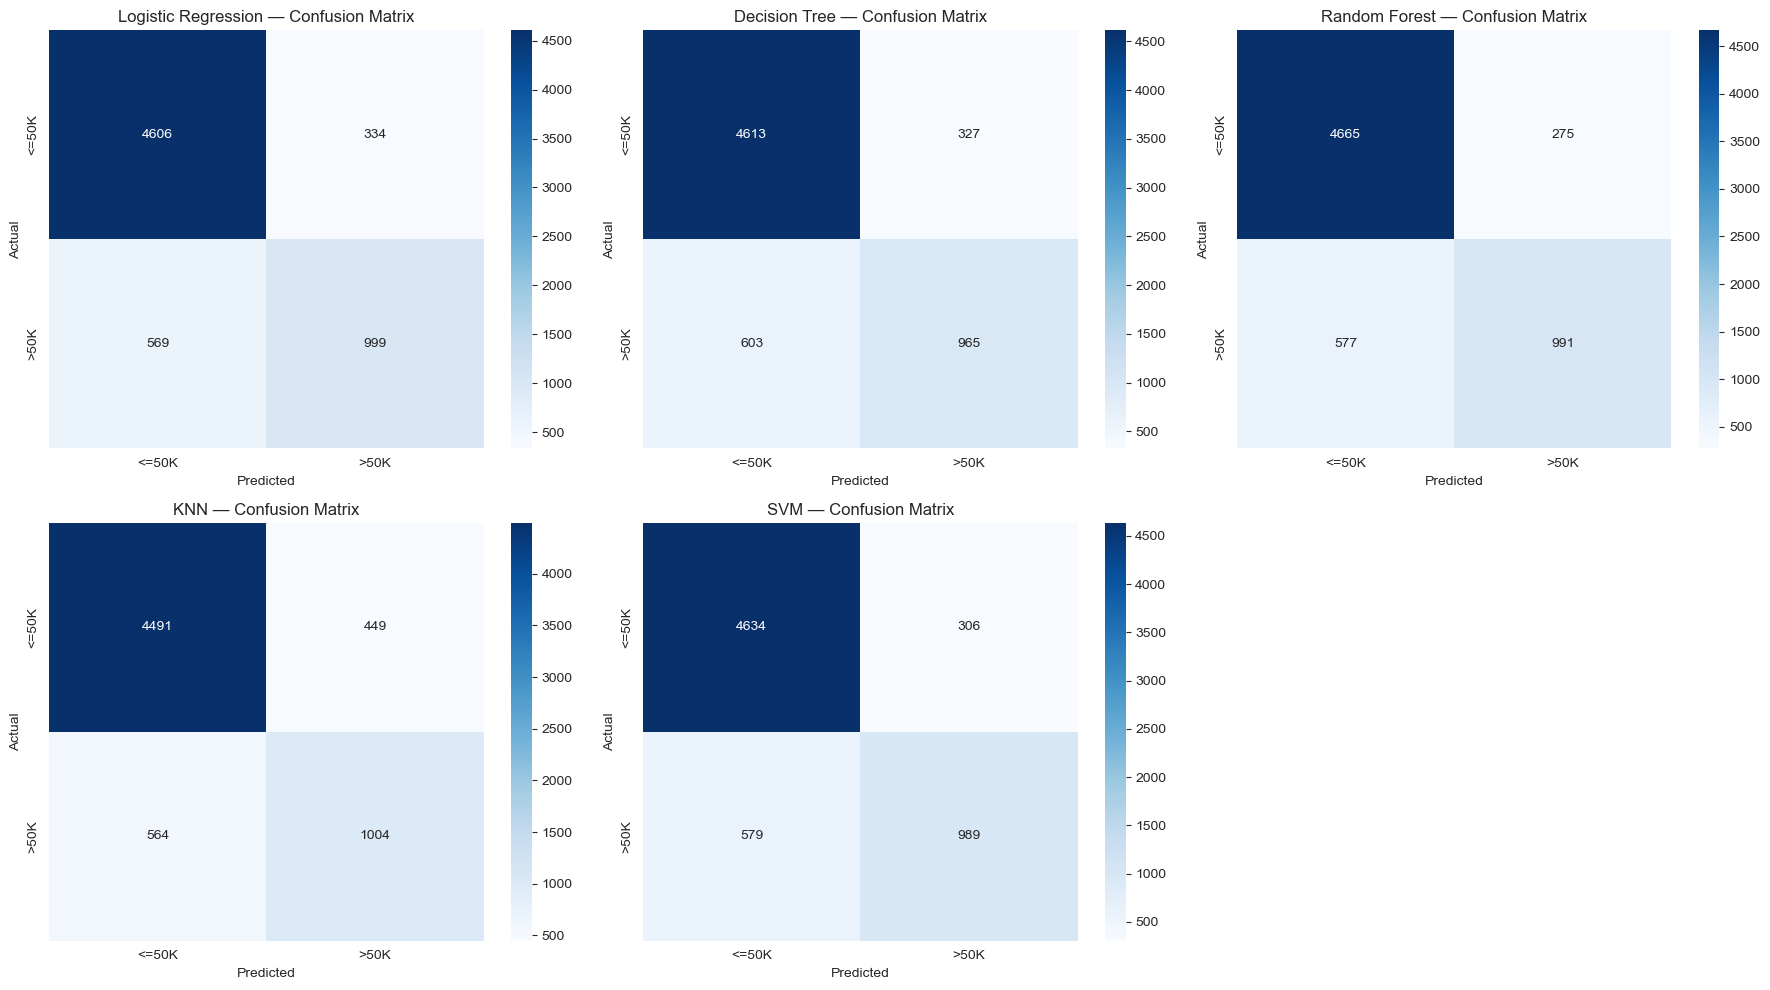

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, est) in enumerate(best_estimators.items()):
    y_pred = est.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
    axes[i].set_title(f"{name} — Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# hide unused subplot
for j in range(len(best_estimators), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [68]:
for name, est in best_estimators.items():
    y_pred = est.predict(X_test)
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))
    print()


===== Logistic Regression =====
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4940
        >50K       0.75      0.64      0.69      1568

    accuracy                           0.86      6508
   macro avg       0.82      0.78      0.80      6508
weighted avg       0.86      0.86      0.86      6508


===== Decision Tree =====
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4940
        >50K       0.75      0.62      0.67      1568

    accuracy                           0.86      6508
   macro avg       0.82      0.77      0.79      6508
weighted avg       0.85      0.86      0.85      6508


===== Random Forest =====
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      4940
        >50K       0.78      0.63      0.70      1568

    accuracy                           0.87      6508
   macro avg       0.84      0.79      0.8

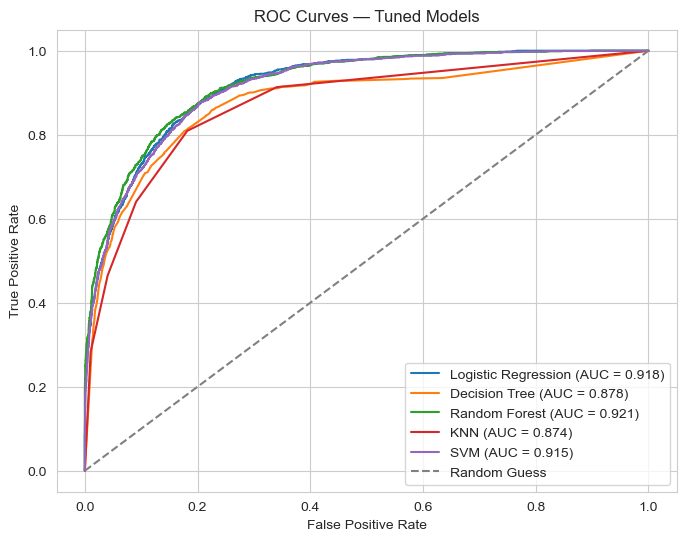

In [69]:
# ROC Curves for all tuned models
plt.figure(figsize=(8, 6))
for name, est in best_estimators.items():
    y_proba = est.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Tuned Models")
plt.legend(loc="lower right")
plt.show()


In [71]:
# Select the best overall model based on F1 score (change this rule if you prefer to optimize for
# a different metric, e.g. ROC-AUC or recall)
best_model_name = tuned_df.iloc[0]["Model"]
best_model = best_estimators[best_model_name]
print(f"Best model selected: {best_model_name}")
print(tuned_df.iloc[0])


Best model selected: Random Forest
Model                                              Random Forest
Best Params    {'classifier__max_depth': 20, 'classifier__min...
Accuracy                                                0.869084
Precision                                                0.78278
Recall                                                  0.632015
F1 Score                                                0.699365
ROC-AUC                                                 0.921376
Name: 0, dtype: object


## 15. Feature Importance

We extract feature importances from a tree-based model (Random Forest / Decision Tree), since these
provide interpretable, built-in importance scores. If the selected best model doesn't natively support
feature importances (e.g. KNN, SVM with rbf kernel), we fall back to displaying the Random Forest's
importances for interpretability purposes.


In [72]:
def get_feature_names(preprocessor_fitted, numerical_features, categorical_features):
    ohe = preprocessor_fitted.named_transformers_["cat"]
    ohe_feature_names = ohe.get_feature_names_out(categorical_features)
    return list(numerical_features) + list(ohe_feature_names)

# Use Random Forest for feature importance (tree-based models expose feature_importances_ directly)
rf_pipeline = best_estimators["Random Forest"]
rf_model = rf_pipeline.named_steps["classifier"]
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = get_feature_names(fitted_preprocessor, numerical_features, categorical_features)
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df.head(20)


,feature,importance
0,education-num,0.128948
1,age,0.101116
2,capital-gain,0.088853
3,capital-net,0.085861
4,marital-status_Married-civ-spouse,0.084436
5,relationship_Husband,0.064768
6,hours-per-week,0.051518
7,marital-status_Never-married,0.027058
8,capital-loss,0.026566
9,has-capital-activity,0.024647


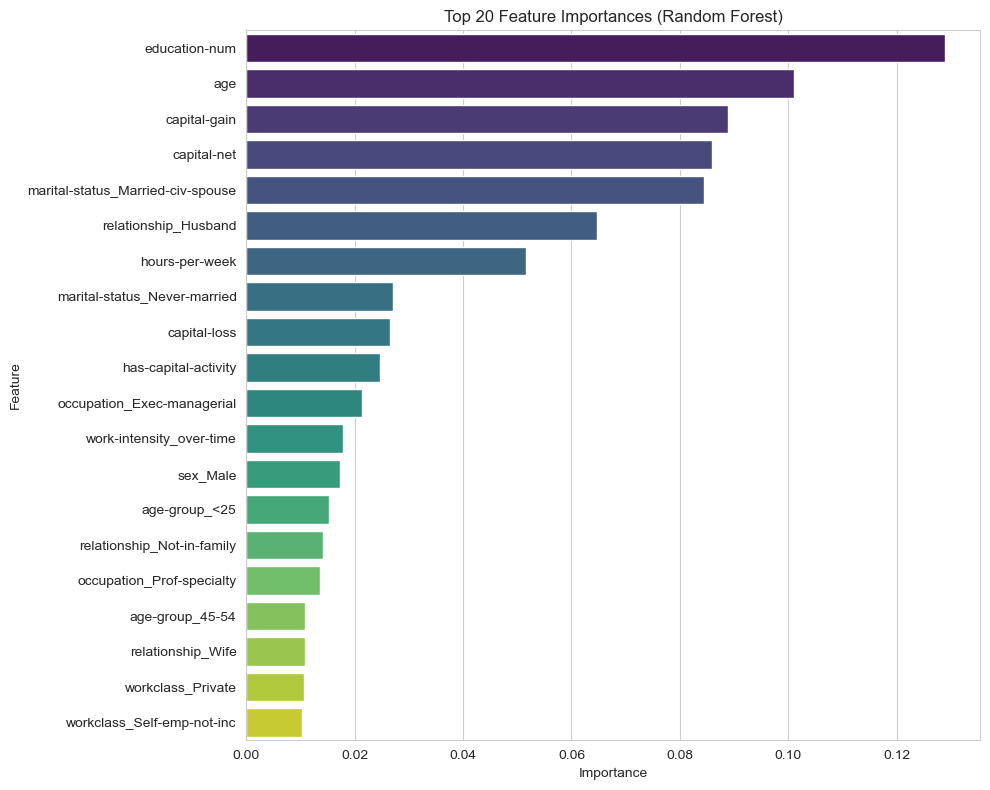

In [73]:
plt.figure(figsize=(10, 8))
top_n = 20
sns.barplot(data=importance_df.head(top_n), x="importance", y="feature", palette="viridis")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 16. Saving the Model with joblib

We save the **entire pipeline** (preprocessing + trained classifier) as a single artifact. This is
important: it means the saved file already knows how to one-hot encode and scale raw input data, so we
never need to separately re-fit or re-save the scaler/encoder.

We also save the label encoder, so predictions (0/1) can be converted back to `<=50K` / `>50K`.


In [74]:
import os

os.makedirs("saved_models", exist_ok=True)

MODEL_PATH = f"saved_models/best_model_{best_model_name.lower().replace(' ', '_')}.joblib"
LABEL_ENCODER_PATH = "saved_models/label_encoder.joblib"

joblib.dump(best_model, MODEL_PATH)
joblib.dump(label_encoder, LABEL_ENCODER_PATH)

print(f"Best model ('{best_model_name}') saved to: {MODEL_PATH}")
print(f"Label encoder saved to: {LABEL_ENCODER_PATH}")


Best model ('Random Forest') saved to: saved_models/best_model_random_forest.joblib
Label encoder saved to: saved_models/label_encoder.joblib


## 17. Loading the Saved Model for New Predictions

Finally, we load the model back from disk (simulating a fresh session / production use) and use it to
predict on new, unseen employee records.


In [75]:
# Load the saved pipeline and label encoder
loaded_model = joblib.load(MODEL_PATH)
loaded_label_encoder = joblib.load(LABEL_ENCODER_PATH)

print("Model and label encoder loaded successfully.")
print(type(loaded_model))


Model and label encoder loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [76]:
# Example: predict on a few rows from the test set (as if they were brand-new records)
sample = X_test.sample(5, random_state=1)

predictions = loaded_model.predict(sample)
probabilities = loaded_model.predict_proba(sample)[:, 1]

results = sample.copy()
results["predicted_income"] = loaded_label_encoder.inverse_transform(predictions)
results["probability_>50K"] = probabilities.round(3)

results[["age", "occupation", "hours-per-week", "education-num", "predicted_income", "probability_>50K"]]


,age,occupation,hours-per-week,education-num,predicted_income,probability_>50K
22269,20,Prof-specialty,32.5,10,<=50K,0.001
5174,25,Sales,32.5,9,<=50K,0.036
17861,36,Exec-managerial,45.0,9,>50K,0.525
14007,28,Adm-clerical,50.0,10,<=50K,0.230
22761,26,Other-service,45.0,10,<=50K,0.003


In [77]:
# Example: predict on a single brand-new, manually defined employee record
new_employee = pd.DataFrame([{
    "age": 42,
    "workclass": "Private",
    "education-num": 13,
    "marital-status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "relationship": "Husband",
    "race": "White",
    "sex": "Male",
    "capital-gain": 5000,
    "capital-loss": 0,
    "hours-per-week": 50,
    "native-country": "United-States",
    "capital-net": 5000,
    "age-group": "35-44",
    "work-intensity": "over-time",
    "is-married": 1,
    "has-capital-activity": 1
}])

pred = loaded_model.predict(new_employee)
proba = loaded_model.predict_proba(new_employee)[:, 1]

predicted_label = loaded_label_encoder.inverse_transform(pred)[0]
print(f"Predicted income class: {predicted_label}")
print(f"Probability of earning >50K: {proba[0]:.2%}")


Predicted income class: <=50K
Probability of earning >50K: 30.94%
